<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/3_farkl%C4%B1_modeller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stellar Classification - MLP ile Çoklu Sınıflandırma**

Bu notebook, Stellar Classification dataseti üzerinde sıfırdan NumPy ile yazılmış bir MLP modelini çoklu sınıflandırma (multiclass) için uyarlamaktadır.

**Adımlar:**

**1. Veri Yükleme ve Keşif Analizi (EDA)**
Veri seti yüklenir; sütun tipleri, eksik değerler ve sınıf dağılımı incelenir.

**2. Ön İşleme**
Bilgi taşımayan ID sütunları çıkarılır. Fotometrik bantlardan (u, g, r, i, z)
astronomik renk indeksleri türetilerek özellik sayısı 8'den 14'e çıkarılır
(özellik mühendisliği). StandardScaler ile standardizasyon uygulanır.
Veri **%70 train / %10 validation / %20 test** olarak tek seferlik bölünür.
Ayrıca Gaussian gürültü eklenerek eğitim seti 2 katına çıkarılır (veri artırma).

**3. N-Katmanlı MLP Fonksiyonları**
Tüm modeller tek bir fonksiyon setiyle çalışır: `initialize_parameters_N`,
`forward_propagation_N`, `backpropagation_N`, `update_parameters_N`,
`nn_model_N`. Katman sayısı `layers` listesiyle belirlenir.
He initialization, tanh (gizli katman) ve Softmax (çıkış katmanı) kullanılır.
L2 regularizasyon `lambda_reg` parametresiyle isteğe bağlı etkinleştirilir.
Mini-batch eğitimi için ayrıca `nn_model_minibatch` fonksiyonu tanımlanmıştır.

**4. Model 1 — Laboratuvar Modeli (1 Gizli Katman)**
Laboratuvarda uygulanan modelin çoklu sınıflandırma uyarlaması: **14 → 32 → 3**.
Train/validation loss ve accuracy eğrileri çizilerek overfitting/underfitting
analizi yapılır. Confusion matrix ve classification report gösterilir.
`n_h` ve `n_steps` üzerinde grid search ile en uygun model seçilir
(val_acc ≥ %90 koşulunu sağlayanlar arasında en düşük n_steps kriteri).

**5. Çok Katmanlı Modeller, Regularizasyon, Veri Artırma ve Mini-Batch**
Overfitting/underfitting problemlerine karşı 9 farklı model karşılaştırılır:

Tüm modeller aynı train/val/test seti üzerinde eğitilir ve karşılaştırılır.
En iyi model val_acc ≥ %90 koşulunu sağlayanlar arasından seçilir.

# **Bölüm 1 — Veri Yükleme ve Keşif Analizi**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
print("\nEksik değer:")
print(df.isnull().sum())


Eksik değer:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [6]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


# **Bölüm 2 — Ön İşleme**

- ID sütunları çıkarılır
- Renk indeksleri türetilir (özellik mühendisliği)
- StandardScaler uygulanır
- Tek seferlik Train / Val / Test split: **%70 / %10 / %20**


In [7]:
# ID sütunlarını sil
drop_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID',
             'spec_obj_ID','plate','MJD','fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

In [8]:
# Özellik mühendisliği: astronomik renk indeksleri
for a, b in [('u','g'), ('g','r'), ('r','i'), ('i','z'), ('u','r')]:
    df_clean[f'{a}_{b}'] = df_clean[a] - df_clean[b]
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

In [9]:
# Label encoding: GALAXY=0, QSO=1, STAR=2
le = LabelEncoder()
y_raw = le.fit_transform(df_clean['class'])
print("Sınıflar:", dict(zip(le.classes_, le.transform(le.classes_))))

Sınıflar: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [10]:
# Özellik matrisi
feature_cols = ['alpha','delta','u','g','r','i','z','redshift',
                'u_g','g_r','r_i','i_z','u_r','redshift_sq']
X_raw = df_clean[feature_cols].values
print("X shape:", X_raw.shape)

X shape: (100000, 14)


In [11]:
# StandardScaler (tek fit: train üzerinde)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [12]:
# Train / Val / Test split — tek seferlik yapılır
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(
    X_scaled, y_raw, test_size=0.30, random_state=42, stratify=y_raw)
X_val, X_test, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_raw, test_size=0.667, random_state=42, stratify=y_temp_raw)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Train: 70000  Val: 9990  Test: 20010


In [13]:
num_classes = 3

def one_hot_encode(y, num_classes):
    """(m,) → (m, num_classes) one-hot matris"""
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

y_train = one_hot_encode(y_train_raw, num_classes)
y_val   = one_hot_encode(y_val_raw,   num_classes)
y_test  = one_hot_encode(y_test_raw,  num_classes)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

y_train: (70000, 3)
y_val  : (9990, 3)
y_test : (20010, 3)


In [14]:
# Veri artırma: eğitim setine Gaussian gürültü ekleyerek 2x büyüt
np.random.seed(0)
noise           = np.random.randn(*X_train.shape) * 0.05
X_train_aug     = np.vstack([X_train, X_train + noise])
y_train_aug_raw = np.hstack([y_train_raw, y_train_raw])
y_train_aug     = one_hot_encode(y_train_aug_raw, num_classes)

print(f"Orijinal train : {X_train.shape[0]}")
print(f"Artırılmış train: {X_train_aug.shape[0]} (2x)")

Orijinal train : 70000
Artırılmış train: 140000 (2x)


# **Bölüm 3 — N-Katmanlı MLP Fonksiyonları**

Tüm modeller (1, 2, 3 gizli katman) aynı fonksiyonlarla çalışır.
`layers` listesi mimariyi tanımlar: örn. `[14, 64, 32, 3]`

- **Gizli katmanlar:** tanh aktivasyonu
- **Çıkış katmanı:** Softmax (çoklu sınıflandırma)
- **Loss:** Categorical Cross-Entropy
- **Init:** He initialization
- **Regularizasyon:** L2 (`lambda_reg` parametresiyle, varsayılan 0)


In [15]:
def softmax(Z):
    """Numerik kararlı softmax. Z: (n_y, m) → (n_y, m)"""
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z   = np.exp(Z_shift)
    return exp_Z / exp_Z.sum(axis=0, keepdims=True)

In [16]:
def compute_cost(A, Y):
    """
    Categorical Cross-Entropy Loss.
    A: (n_y, m) softmax çıktısı
    Y: (m, n_y) one-hot hedef
    """
    m = A.shape[1]
    return float(-np.sum(Y.T * np.log(A + 1e-8)) / m)

In [17]:
def initialize_parameters_N(layers):
    """
    layers: [n_x, n_h1, ..., n_y]
    He initialization: W ~ N(0, sqrt(2/n_in))
    """
    np.random.seed(42)
    parameters = {}
    for i in range(1, len(layers)):
        parameters[f'W{i}'] = np.random.randn(layers[i], layers[i-1]) * np.sqrt(2.0 / layers[i-1])
        parameters[f'b{i}'] = np.zeros((layers[i], 1))
    return parameters

# Boyut kontrolü
p_test = initialize_parameters_N([14, 32, 3])
print("W1:", p_test['W1'].shape, "W2:", p_test['W2'].shape)

W1: (32, 14) W2: (3, 32)


In [18]:
def forward_propagation_N(X, parameters, L):
    """
    X: (m, n_x)
    L: toplam katman sayısı (gizli + çıkış)
    Gizli katmanlar → tanh  |  Çıkış → softmax
    """
    cache = {'A0': X.T}
    A = X.T
    for i in range(1, L):
        Z = np.dot(parameters[f'W{i}'], A) + parameters[f'b{i}']
        A = np.tanh(Z)
        cache[f'A{i}'] = A
    Z = np.dot(parameters[f'W{L}'], A) + parameters[f'b{L}']
    A = softmax(Z)
    cache[f'A{L}'] = A
    return A, cache

In [19]:
def backpropagation_N(X, Y, cache, parameters, L, lambda_reg=0.0):
    """
    Softmax + Categorical CE türevi: dZ_L = A_L - Y.T
    lambda_reg=0.0 → regularizasyon yok
    lambda_reg>0.0 → L2 regularizasyon: gradient'e (lambda/m)*W eklenir
    """
    m = X.shape[0]
    grads = {}
    dA = cache[f'A{L}'] - Y.T
    for i in range(L, 0, -1):
        A_prev = cache[f'A{i-1}']
        grads[f'dW{i}'] = np.dot(dA, A_prev.T) / m + (lambda_reg / m) * parameters[f'W{i}']
        grads[f'db{i}'] = np.sum(dA, axis=1, keepdims=True) / m
        if i > 1:
            dA = np.dot(parameters[f'W{i}'].T, dA) * (1 - A_prev ** 2)
    return grads

In [20]:
def update_parameters_N(parameters, grads, L, learning_rate):
    for i in range(1, L + 1):
        parameters[f'W{i}'] -= learning_rate * grads[f'dW{i}']
        parameters[f'b{i}'] -= learning_rate * grads[f'db{i}']
    return parameters

In [21]:
def nn_model_N(X, Y, layers, n_steps=300, learning_rate=0.5, lambda_reg=0.0,
               X_val=None, Y_val=None, y_val_raw=None, print_cost=True):
    """
    Genel N-katmanlı MLP eğitim fonksiyonu.
    layers     : mimari listesi, örn. [14, 64, 32, 3]
    lambda_reg : 0 → yok  |  >0 → L2 regularizasyon
    X_val/Y_val: verilirse her 10 adımda validation metriği hesaplanır
    """
    L = len(layers) - 1
    parameters = initialize_parameters_N(layers)
    train_costs, val_costs, train_accs, val_accs = [], [], [], []

    for i in range(n_steps):
        A, cache  = forward_propagation_N(X, parameters, L)
        grads     = backpropagation_N(X, Y, cache, parameters, L, lambda_reg)
        parameters = update_parameters_N(parameters, grads, L, learning_rate)

        if i % 10 == 0:
            cost_tr = compute_cost(A, Y)
            acc_tr  = accuracy_score(np.argmax(Y, axis=1), np.argmax(A, axis=0))
            train_costs.append(cost_tr)
            train_accs.append(acc_tr)

            if X_val is not None:
                A_val, _ = forward_propagation_N(X_val, parameters, L)
                val_costs.append(compute_cost(A_val, Y_val))
                val_accs.append(accuracy_score(y_val_raw, np.argmax(A_val, axis=0)))

            if print_cost and i % 50 == 0:
                msg = f"step {i:3d} | loss={cost_tr:.4f} | train_acc={acc_tr:.4f}"
                if X_val is not None:
                    msg += f" | val_acc={val_accs[-1]:.4f}"
                print(msg)

    return parameters, train_costs, val_costs, train_accs, val_accs

In [22]:
def predict_N(parameters, X, L):
    """En yüksek softmax olasılığını sınıf olarak döndürür."""
    A, _ = forward_propagation_N(X, parameters, L)
    return np.argmax(A, axis=0)

# **Bölüm 4 — Model 1: 1 Gizli Katman (Laboratuvar Modeli)**

Mimari: **14 → 32 → 3**

Bu model 13.03.2026 tarihinde laboratuvarda uygulanan 2 katmanlı (1 gizli katmanlı)
modelin çoklu sınıflandırma için uyarlanmış halidir.


In [23]:
print("Model 1 eğitimi: 14 → 32 → 3")
print("-" * 55)

layers_m1 = [14, 32, 3]
L_m1 = len(layers_m1) - 1

params_m1, tc_m1, vc_m1, ta_m1, va_m1 = nn_model_N(
    X_train, y_train, layers_m1,
    n_steps=300, learning_rate=0.5, lambda_reg=0.0,
    X_val=X_val, Y_val=y_val, y_val_raw=y_val_raw,
    print_cost=True
)

Model 1 eğitimi: 14 → 32 → 3
-------------------------------------------------------
step   0 | loss=1.0612 | train_acc=0.4503 | val_acc=0.6912
step  50 | loss=0.3194 | train_acc=0.8839 | val_acc=0.8850
step 100 | loss=0.2459 | train_acc=0.9238 | val_acc=0.9238
step 150 | loss=0.2143 | train_acc=0.9364 | val_acc=0.9349
step 200 | loss=0.1956 | train_acc=0.9425 | val_acc=0.9405
step 250 | loss=0.2011 | train_acc=0.9263 | val_acc=0.9339


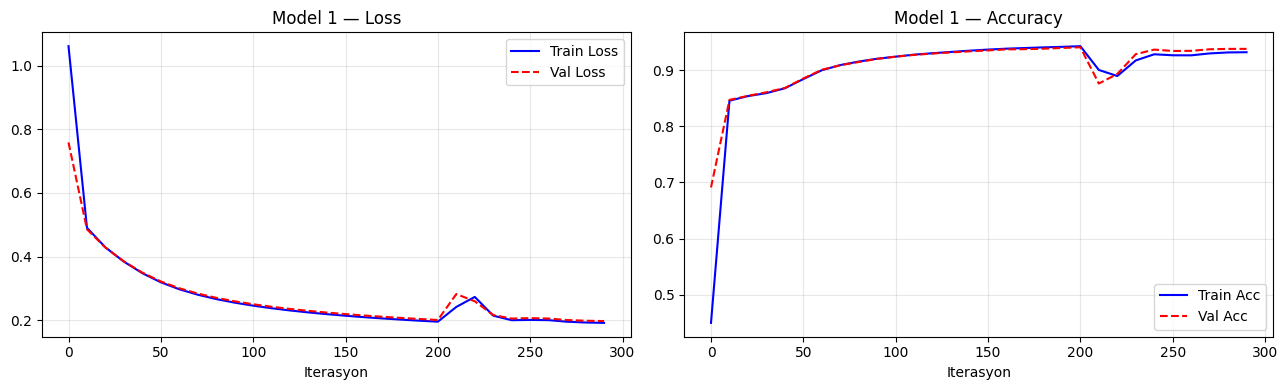

In [24]:
# Overfitting / Underfitting Analizi — Loss ve Accuracy grafikleri
steps_ax = list(range(0, len(tc_m1) * 10, 10))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(steps_ax, tc_m1, 'b-',  label='Train Loss')
ax1.plot(steps_ax, vc_m1, 'r--', label='Val Loss')
ax1.set_title('Model 1 — Loss'); ax1.set_xlabel('Iterasyon')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(steps_ax, ta_m1, 'b-',  label='Train Acc')
ax2.plot(steps_ax, va_m1, 'r--', label='Val Acc')
ax2.set_title('Model 1 — Accuracy'); ax2.set_xlabel('Iterasyon')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [25]:
y_pred_m1 = predict_N(params_m1, X_test, L_m1)

acc_tr = ta_m1[-1]
acc_va = va_m1[-1]
acc_te = accuracy_score(y_test_raw, y_pred_m1)
gap    = acc_tr - acc_va

print("=" * 50)
print(f"Train      Accuracy : {acc_tr:.4f}")
print(f"Validation Accuracy : {acc_va:.4f}")
print(f"Test       Accuracy : {acc_te:.4f}")
print(f"Train - Val Gap     : {gap:.4f}")
print("=" * 50)

if gap > 0.05:
    print("Durum: OVERFITTING — Regularizasyon veya daha az nöron deneyin.")
elif acc_tr < 0.85:
    print("Durum: UNDERFITTING — Daha fazla nöron veya iterasyon deneyin.")
else:
    print("Durum: Iyi fit")

print()
print("Classification Report (Test):")
print(classification_report(y_test_raw, y_pred_m1, target_names=le.classes_))

Train      Accuracy : 0.9317
Validation Accuracy : 0.9376
Test       Accuracy : 0.9326
Train - Val Gap     : -0.0060
Durum: Iyi fit

Classification Report (Test):
              precision    recall  f1-score   support

      GALAXY       0.92      0.97      0.94     11895
         QSO       0.95      0.89      0.92      3794
        STAR       0.94      0.88      0.91      4321

    accuracy                           0.93     20010
   macro avg       0.94      0.91      0.92     20010
weighted avg       0.93      0.93      0.93     20010



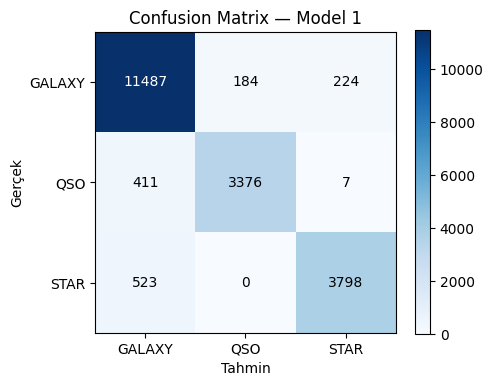

In [26]:
# Confusion Matrix — Model 1
cm = confusion_matrix(y_test_raw, y_pred_m1)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im)
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(le.classes_);  ax.set_yticklabels(le.classes_)
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
ax.set_title('Confusion Matrix — Model 1')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

In [27]:
# Model seçim kriteri: val_acc >= %90 ise en düşük n_steps
print("Hiperparametre arama — Model 1 (1 gizli katman)")
print("-" * 60)

candidates = []
for n_h in [16, 32, 64]:
    for n_step in [200, 300, 500]:
        p, _, _, _, va = nn_model_N(
            X_train, y_train, [14, n_h, 3],
            n_steps=n_step, learning_rate=0.5,
            X_val=X_val, Y_val=y_val, y_val_raw=y_val_raw,
            print_cost=False
        )
        acc_v = va[-1]
        acc_t = accuracy_score(y_test_raw, predict_N(p, X_test, 2))
        candidates.append({'n_h': n_h, 'n_steps': n_step, 'val_acc': acc_v, 'test_acc': acc_t})
        print(f"n_h={n_h:3d}, n_steps={n_step} | val_acc={acc_v:.4f} | test_acc={acc_t:.4f}")

passing = [c for c in candidates if c['val_acc'] >= 0.90]
best_m1 = min(passing, key=lambda x: x['n_steps']) if passing else max(candidates, key=lambda x: x['val_acc'])
print(f"\nSeçilen model: n_h={best_m1['n_h']}, n_steps={best_m1['n_steps']}")
print(f"Val Acc={best_m1['val_acc']:.4f}, Test Acc={best_m1['test_acc']:.4f}")

Hiperparametre arama — Model 1 (1 gizli katman)
------------------------------------------------------------
n_h= 16, n_steps=200 | val_acc=0.9189 | test_acc=0.9360
n_h= 16, n_steps=300 | val_acc=0.9319 | test_acc=0.9398
n_h= 16, n_steps=500 | val_acc=0.9463 | test_acc=0.9467
n_h= 32, n_steps=200 | val_acc=0.9392 | test_acc=0.9443
n_h= 32, n_steps=300 | val_acc=0.9376 | test_acc=0.9326
n_h= 32, n_steps=500 | val_acc=0.9474 | test_acc=0.9465
n_h= 64, n_steps=200 | val_acc=0.9397 | test_acc=0.9442
n_h= 64, n_steps=300 | val_acc=0.9397 | test_acc=0.9326
n_h= 64, n_steps=500 | val_acc=0.9479 | test_acc=0.9491

Seçilen model: n_h=16, n_steps=200
Val Acc=0.9189, Test Acc=0.9360


# **Bölüm 5 — Çok Katmanlı Modeller, Regularizasyon, Veri Artırma ve Mini-Batch**

| Model | Mimari | Teknik |
|-------|--------|--------|
| M1 | 14→32→3 | Temel model (1 gizli katman) |
| M2 | 14→64→3 | Nöron sayısı artırma |
| M3 | 14→128→3 | Daha fazla nöron |
| M4 | 14→64→32→3 | 2 gizli katman |
| M5 | 14→64→32→3 | 2 gizli katman + L2 regularizasyon |
| M6 | 14→64→32→16→3 | 3 gizli katman |
| M7 | 14→64→32→3 | 2 gizli katman + veri artırma |
| M8 | 14→64→32→3 | Mini-batch (batch=512) |
| M9 | 14→64→32→3 | Mini-batch + L2 regularizasyon |


In [28]:
def nn_model_minibatch(X, Y, layers, n_epochs=30, learning_rate=0.1,
                       batch_size=512, lambda_reg=0.0,
                       X_val=None, Y_val=None, y_val_raw=None, print_cost=True):
    """
    Mini-batch SGD ile N-katmanlı MLP eğitimi.

    Her epoch:
      1. Veri rastgele karıştırılır
      2. batch_size'lık parçalara bölünür
      3. Her parça için forward → backprop → update yapılır
      4. Epoch sonu train/val metrikleri kaydedilir

    batch_size = len(X) → full-batch (klasik gradient descent)
    batch_size = 256/512 → mini-batch SGD
    """
    L = len(layers) - 1
    parameters = initialize_parameters_N(layers)
    m = X.shape[0]
    train_costs, val_costs, train_accs, val_accs = [], [], [], []

    for epoch in range(n_epochs):
        # Her epoch'ta veriyi karıştır
        shuffle_idx = np.random.permutation(m)
        X_sh, Y_sh  = X[shuffle_idx], Y[shuffle_idx]

        # Mini-batch'lere böl ve eğit
        for start in range(0, m, batch_size):
            X_batch = X_sh[start : start + batch_size]
            Y_batch = Y_sh[start : start + batch_size]
            A_b, cache_b = forward_propagation_N(X_batch, parameters, L)
            grads        = backpropagation_N(X_batch, Y_batch, cache_b, parameters, L, lambda_reg)
            parameters   = update_parameters_N(parameters, grads, L, learning_rate)

        # Epoch sonu metrik (tüm train seti üzerinde)
        A_tr, _ = forward_propagation_N(X, parameters, L)
        c_tr    = compute_cost(A_tr, Y)
        acc_tr  = accuracy_score(np.argmax(Y, axis=1), np.argmax(A_tr, axis=0))
        train_costs.append(c_tr)
        train_accs.append(acc_tr)

        if X_val is not None:
            A_v, _ = forward_propagation_N(X_val, parameters, L)
            val_costs.append(compute_cost(A_v, Y_val))
            val_accs.append(accuracy_score(y_val_raw, np.argmax(A_v, axis=0)))

        if print_cost and epoch % 5 == 0:
            msg = f'epoch {epoch:3d} | loss={c_tr:.4f} | train_acc={acc_tr:.4f}'
            if X_val is not None:
                msg += f' | val_acc={val_accs[-1]:.4f}'
            print(msg)

    return parameters, train_costs, val_costs, train_accs, val_accs

In [29]:
model_configs = [
    {'name': 'M1: 1 gizli n_h=32',       'layers': [14, 32, 3],         'lam': 0.0,  'aug': False, 'mb': False},
    {'name': 'M2: 1 gizli n_h=64',        'layers': [14, 64, 3],         'lam': 0.0,  'aug': False, 'mb': False},
    {'name': 'M3: 1 gizli n_h=128',       'layers': [14, 128, 3],        'lam': 0.0,  'aug': False, 'mb': False},
    {'name': 'M4: 2 gizli 64-32',         'layers': [14, 64, 32, 3],     'lam': 0.0,  'aug': False, 'mb': False},
    {'name': 'M5: 2 gizli +L2',           'layers': [14, 64, 32, 3],     'lam': 0.01, 'aug': False, 'mb': False},
    {'name': 'M6: 3 gizli 64-32-16',      'layers': [14, 64, 32, 16, 3], 'lam': 0.0,  'aug': False, 'mb': False},
    {'name': 'M7: 2 gizli +veri artırma', 'layers': [14, 64, 32, 3],     'lam': 0.0,  'aug': True,  'mb': False},
    {'name': 'M8: Mini-batch',             'layers': [14, 64, 32, 3],     'lam': 0.0,  'aug': False, 'mb': True},
    {'name': 'M9: Mini-batch+L2',          'layers': [14, 64, 32, 3],     'lam': 0.01, 'aug': False, 'mb': True},
]

all_results = []

for cfg in model_configs:
    Xtr  = X_train_aug     if cfg['aug'] else X_train
    Ytr  = y_train_aug     if cfg['aug'] else y_train
    ytr  = y_train_aug_raw if cfg['aug'] else y_train_raw
    L    = len(cfg['layers']) - 1

    print(f"\n>>> {cfg['name']}")
    np.random.seed(42)

    if cfg['mb']:
        # Mini-batch: 30 epoch, batch_size=512
        params, tc, vc, ta, va = nn_model_minibatch(
            Xtr, Ytr, cfg['layers'],
            n_epochs=30, learning_rate=0.1, batch_size=512,
            lambda_reg=cfg['lam'],
            X_val=X_val, Y_val=y_val, y_val_raw=y_val_raw,
            print_cost=True
        )
    else:
        # Full-batch: 300 adım
        params, tc, vc, ta, va = nn_model_N(
            Xtr, Ytr, cfg['layers'],
            n_steps=300, learning_rate=0.5, lambda_reg=cfg['lam'],
            X_val=X_val, Y_val=y_val, y_val_raw=y_val_raw,
            print_cost=True
        )

    test_acc = accuracy_score(y_test_raw, predict_N(params, X_test, L))
    all_results.append({
        'name': cfg['name'], 'layers': cfg['layers'],
        'params': params, 'L': L,
        'tc': tc, 'vc': vc, 'ta': ta, 'va': va,
        'test_acc': test_acc, 'gap': ta[-1] - va[-1]
    })


>>> M1: 1 gizli n_h=32
step   0 | loss=1.0612 | train_acc=0.4503 | val_acc=0.6912
step  50 | loss=0.3194 | train_acc=0.8839 | val_acc=0.8850
step 100 | loss=0.2459 | train_acc=0.9238 | val_acc=0.9238
step 150 | loss=0.2143 | train_acc=0.9364 | val_acc=0.9349
step 200 | loss=0.1956 | train_acc=0.9425 | val_acc=0.9405
step 250 | loss=0.2011 | train_acc=0.9263 | val_acc=0.9339

>>> M2: 1 gizli n_h=64
step   0 | loss=1.3428 | train_acc=0.3129 | val_acc=0.6904
step  50 | loss=0.2913 | train_acc=0.9048 | val_acc=0.9049
step 100 | loss=0.2333 | train_acc=0.9272 | val_acc=0.9249
step 150 | loss=0.2057 | train_acc=0.9370 | val_acc=0.9342
step 200 | loss=0.1886 | train_acc=0.9428 | val_acc=0.9419
step 250 | loss=0.2216 | train_acc=0.9085 | val_acc=0.9227

>>> M3: 1 gizli n_h=128
step   0 | loss=0.9776 | train_acc=0.5244 | val_acc=0.7558
step  50 | loss=0.3010 | train_acc=0.8802 | val_acc=0.9005
step 100 | loss=0.2544 | train_acc=0.8988 | val_acc=0.9182
step 150 | loss=0.2249 | train_acc=0.9122 

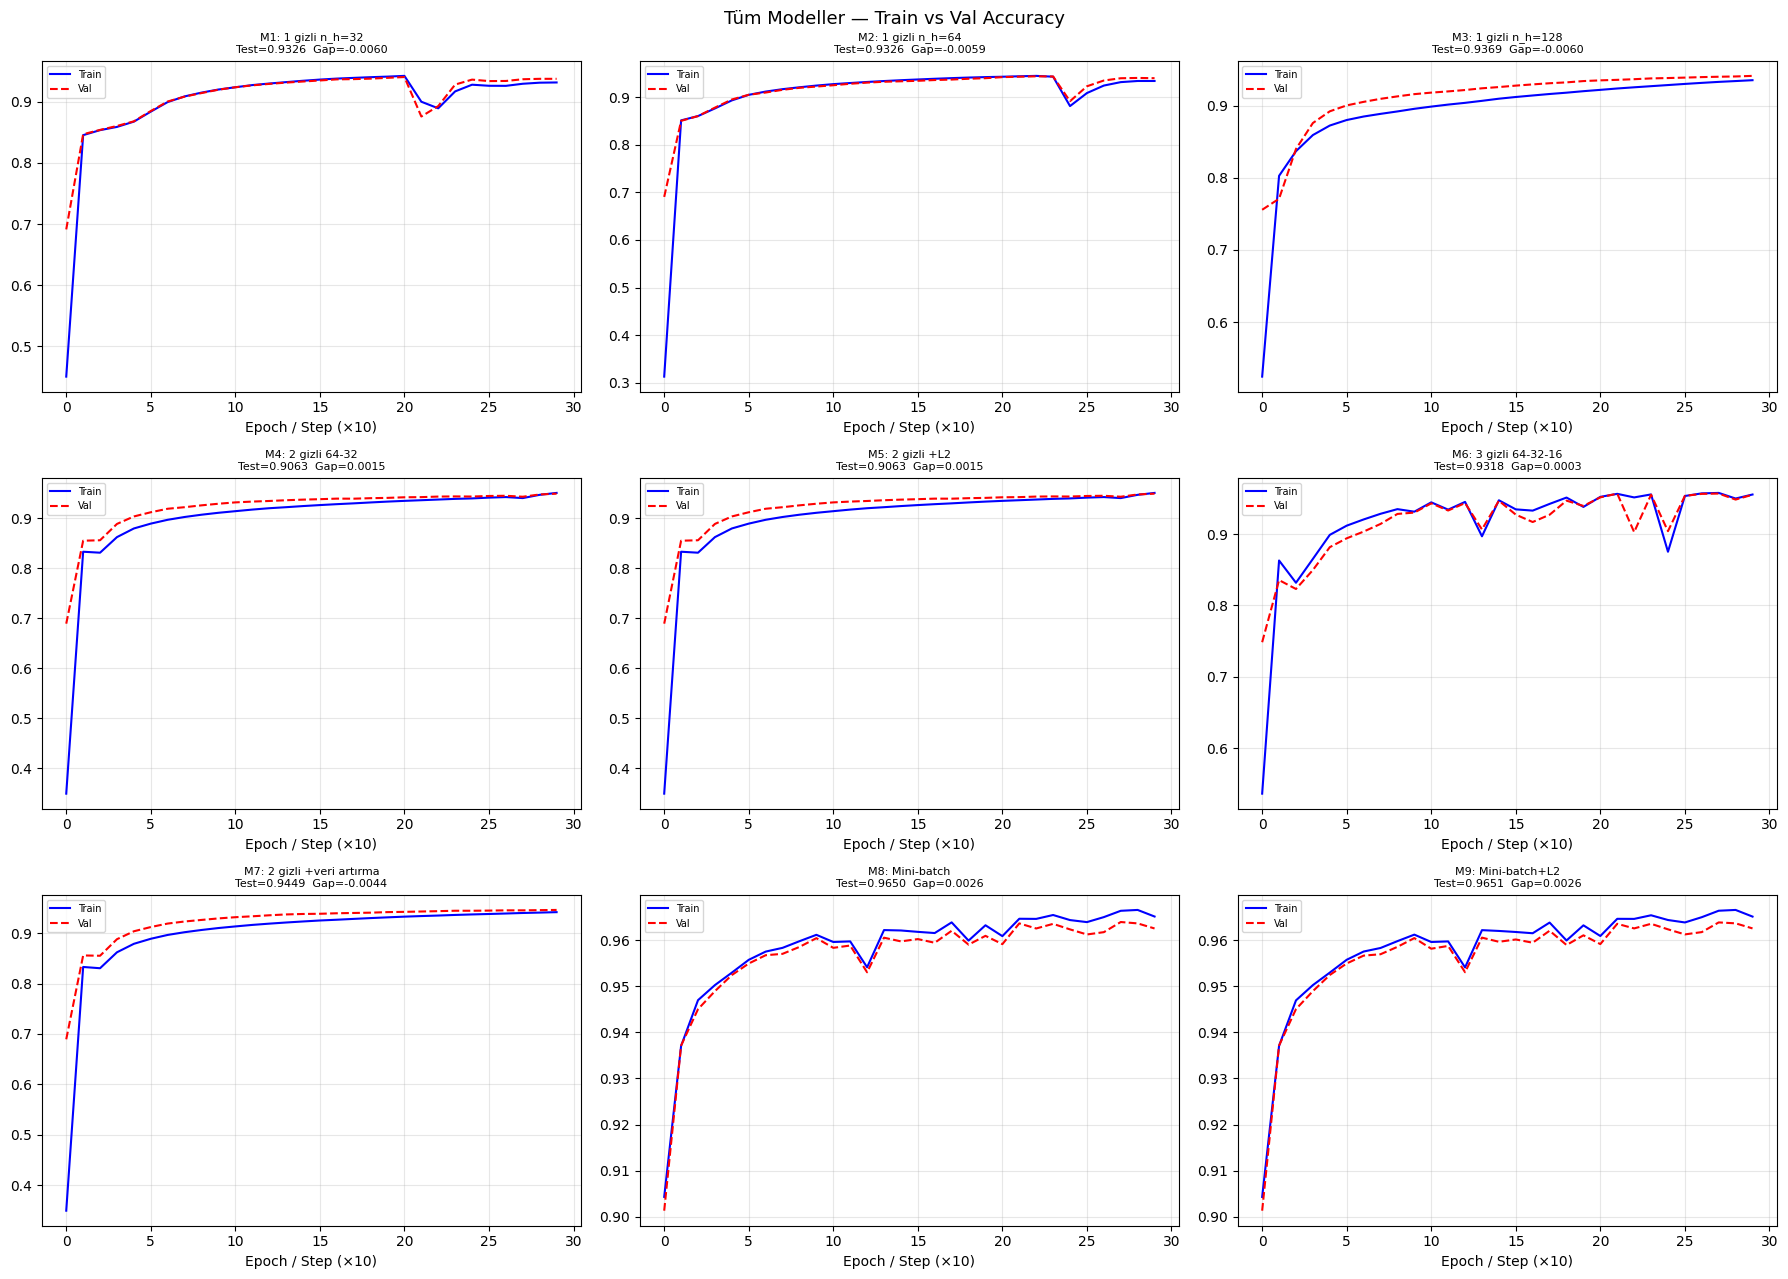

In [30]:
# Tüm 9 modelin accuracy eğrileri
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for idx, r in enumerate(all_results):
    s = list(range(len(r['ta'])))
    axes[idx].plot(s, r['ta'], 'b-',  label='Train')
    axes[idx].plot(s, r['va'], 'r--', label='Val')
    axes[idx].set_title(
        f"{r['name']}\nTest={r['test_acc']:.4f}  Gap={r['gap']:.4f}", fontsize=8)
    axes[idx].set_xlabel('Epoch / Step (×10)')
    axes[idx].legend(fontsize=7); axes[idx].grid(alpha=0.3)

for idx in range(len(all_results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Tüm Modeller — Train vs Val Accuracy', fontsize=13)
plt.tight_layout(); plt.show()

In [31]:
# Özet karşılaştırma tablosu — tüm modeller
print(f"{'Model':<30} {'Train':>7} {'Val':>7} {'Test':>7} {'Gap':>8}  Durum")
print("-" * 75)

for r in all_results:
    tr  = r['ta'][-1]; va = r['va'][-1]; gap = r['gap']
    durum = 'Overfitting' if gap > 0.05 else ('Underfitting' if tr < 0.88 else 'Iyi fit')
    print(f"{r['name']:<30} {tr:>7.4f} {va:>7.4f} {r['test_acc']:>7.4f} {gap:>8.4f}  {durum}")

# Seçim: val_acc >= %90 olanlar arasından en yüksek test_acc
passing = [r for r in all_results if r['va'][-1] >= 0.90]
best = max(passing, key=lambda x: x['test_acc']) if passing else max(all_results, key=lambda x: x['test_acc'])
print(f"\nEn iyi model: {best['name']}  Test Acc={best['test_acc']:.4f}")


Model                            Train     Val    Test      Gap  Durum
---------------------------------------------------------------------------
M1: 1 gizli n_h=32              0.9317  0.9376  0.9326  -0.0060  Iyi fit
M2: 1 gizli n_h=64              0.9339  0.9397  0.9326  -0.0059  Iyi fit
M3: 1 gizli n_h=128             0.9355  0.9414  0.9369  -0.0060  Iyi fit
M4: 2 gizli 64-32               0.9505  0.9489  0.9063   0.0015  Iyi fit
M5: 2 gizli +L2                 0.9505  0.9489  0.9063   0.0015  Iyi fit
M6: 3 gizli 64-32-16            0.9554  0.9552  0.9318   0.0003  Iyi fit
M7: 2 gizli +veri artırma       0.9415  0.9459  0.9449  -0.0044  Iyi fit
M8: Mini-batch                  0.9652  0.9626  0.9650   0.0026  Iyi fit
M9: Mini-batch+L2               0.9651  0.9626  0.9651   0.0026  Iyi fit

En iyi model: M9: Mini-batch+L2  Test Acc=0.9651


Classification Report — M9: Mini-batch+L2:
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     11895
         QSO       0.96      0.92      0.94      3794
        STAR       0.95      1.00      0.97      4321

    accuracy                           0.97     20010
   macro avg       0.96      0.96      0.96     20010
weighted avg       0.97      0.97      0.96     20010



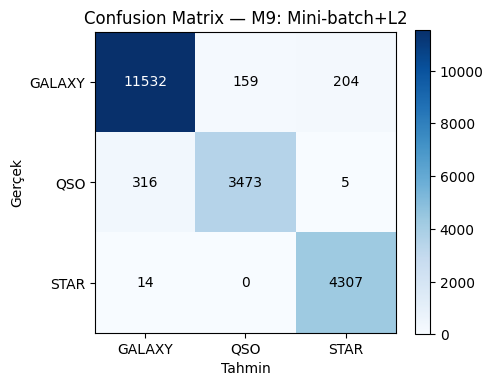

In [32]:
# En iyi modelin detaylı metrikleri
y_pred_best = predict_N(best['params'], X_test, best['L'])

print(f"Classification Report — {best['name']}:")
print(classification_report(y_test_raw, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test_raw, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im)
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(le.classes_);  ax.set_yticklabels(le.classes_)
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
ax.set_title(f'Confusion Matrix — {best["name"]}')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()